In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("car_Dekho_DA.csv")

print(df.head())

  Car_Name  Year  Selling_Price  Present_Price  Kms_Driven Fuel_Type  \
0     ritz  2014           3.35           5.59       27000    Petrol   
1      sx4  2013           4.75           9.54       43000    Diesel   
2     ciaz  2017           7.25           9.85        6900    Petrol   
3  wagon r  2011           2.85           4.15        5200    Petrol   
4    swift  2014           4.60           6.87       42450    Diesel   

  Seller_Type Transmission  Owner  
0      Dealer       Manual      0  
1      Dealer       Manual      0  
2      Dealer       Manual      0  
3      Dealer       Manual      0  
4      Dealer       Manual      0  


In [4]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 301
Columns: 9


In [5]:
print(df.columns)

Index(['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Kms_Driven',
       'Fuel_Type', 'Seller_Type', 'Transmission', 'Owner'],
      dtype='object')


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [7]:
print(df.isnull().sum())

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64


In [8]:
print(df.describe())

              Year  Selling_Price  Present_Price     Kms_Driven       Owner
count   301.000000     301.000000     301.000000     301.000000  301.000000
mean   2013.627907       4.661296       7.628472   36947.205980    0.043189
std       2.891554       5.082812       8.644115   38886.883882    0.247915
min    2003.000000       0.100000       0.320000     500.000000    0.000000
25%    2012.000000       0.900000       1.200000   15000.000000    0.000000
50%    2014.000000       3.600000       6.400000   32000.000000    0.000000
75%    2016.000000       6.000000       9.900000   48767.000000    0.000000
max    2018.000000      35.000000      92.600000  500000.000000    3.000000


In [9]:
print("Oldest Year:", df["Year"].min())
print("Newest Year:", df["Year"].max())

Oldest Year: 2003
Newest Year: 2018


In [10]:
print("Lowest Selling Price:", df["Selling_Price"].min())

Lowest Selling Price: 0.1


In [11]:
print("Total Records:", len(df))

Total Records: 301


In [12]:
print("Total Missing Values:", df.isnull().sum().sum())

Total Missing Values: 0


In [13]:
print("Different Vehicles:", df["Car_Name"].nunique())

Different Vehicles: 98


In [14]:
print(df["Car_Name"].value_counts().head(10))

Car_Name
city             26
corolla altis    16
verna            14
fortuner         11
brio             10
ciaz              9
innova            9
i20               9
grand i10         8
jazz              7
Name: count, dtype: int64


In [15]:
print("Most Sold Vehicle:")
print(df["Car_Name"].value_counts().idxmax())

Most Sold Vehicle:
city


In [16]:
print("CNG Vehicles:", (df["Fuel_Type"] == "CNG").sum())

CNG Vehicles: 2


In [17]:
print("Individual Sellers:",
      (df["Seller_Type"] == "Individual").sum())

Individual Sellers: 106


In [18]:
print("Automatic Vehicles:",
      (df["Transmission"] == "Automatic").sum())

Automatic Vehicles: 40


In [20]:
print("First Owner Vehicles:",
      (df["Owner"] == 0).sum())

First Owner Vehicles: 290


In [21]:
df["Depreciation"] = df["Present_Price"] - df["Selling_Price"]

print(df[["Car_Name", "Present_Price",
          "Selling_Price", "Depreciation"]].head())

  Car_Name  Present_Price  Selling_Price  Depreciation
0     ritz           5.59           3.35          2.24
1      sx4           9.54           4.75          4.79
2     ciaz           9.85           7.25          2.60
3  wagon r           4.15           2.85          1.30
4    swift           6.87           4.60          2.27


In [22]:
most = df.loc[df["Depreciation"].idxmax()]

print(most[[
    "Car_Name",
    "Present_Price",
    "Selling_Price",
    "Depreciation"
]])

Car_Name         land cruiser
Present_Price            92.6
Selling_Price            35.0
Depreciation             57.6
Name: 86, dtype: object


In [23]:
least = df.loc[df["Depreciation"].idxmin()]

print(least[[
    "Car_Name",
    "Present_Price",
    "Selling_Price",
    "Depreciation"
]])

Car_Name         Honda Activa 4G
Present_Price               0.51
Selling_Price               0.48
Depreciation                0.03
Name: 155, dtype: object


In [24]:
def get_brand(name):
    return name.split()[0].title()

df["Brand"] = df["Car_Name"].apply(get_brand)

brand_depreciation = df.groupby("Brand")["Depreciation"].mean()

print(brand_depreciation.sort_values())

Brand
Um           0.120000
Activa       0.183333
Tvs          0.242750
Mahindra     0.250000
Yamaha       0.258750
Hero         0.265200
Honda        0.318824
Suzuki       0.330000
Bajaj        0.334400
Royal        0.423529
Vitara       0.580000
Ktm          0.745000
Grand        0.756250
Ignis        0.810000
Alto         1.166667
Brio         1.299000
Omni         1.440000
I10          1.506000
Eon          1.530000
Creta        1.800000
Swift        1.802000
800          1.930000
Wagon        1.937500
Baleno       2.020000
Hyosung      2.100000
S            2.110000
Xcent        2.163333
Ciaz         2.284444
Jazz         2.328571
I20          2.438889
Ritz         2.475000
Amaze        2.564286
Etios        2.848182
Ertiga       2.848333
Dzire        3.157500
Elantra      3.190000
Verna        3.292143
City         4.372692
Sx4          4.908333
Innova       5.068889
Corolla     10.425882
Fortuner    12.047273
Camry       21.230000
Land        57.600000
Name: Depreciation, dtype:

In [25]:
df["Age"] = 2019 - df["Year"]

print(df[["Car_Name", "Year", "Age"]].head())

  Car_Name  Year  Age
0     ritz  2014    5
1      sx4  2013    6
2     ciaz  2017    2
3  wagon r  2011    8
4    swift  2014    5


In [26]:
print(
    "Age vs Depreciation:",
    df["Age"].corr(df["Depreciation"])
)

Age vs Depreciation: 0.33374609824378804


In [27]:
print(
    "Kms vs Depreciation:",
    df["Kms_Driven"].corr(df["Depreciation"])
)

Kms vs Depreciation: 0.33383151920794224


In [28]:
print(
    "Age vs Selling Price:",
    df["Age"].corr(df["Selling_Price"])
)

print(
    "Kms vs Selling Price:",
    df["Kms_Driven"].corr(df["Selling_Price"])
)

Age vs Selling Price: -0.23614098016042756
Kms vs Selling Price: 0.029187090674291354


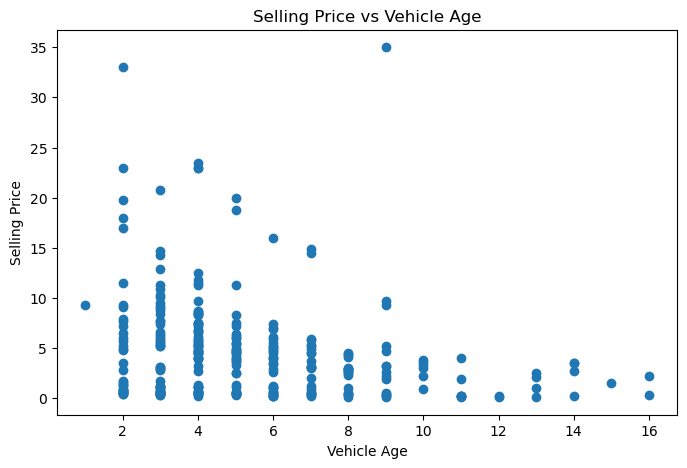

In [29]:
plt.figure(figsize=(8,5))

plt.scatter(df["Age"], df["Selling_Price"])

plt.xlabel("Vehicle Age")
plt.ylabel("Selling Price")
plt.title("Selling Price vs Vehicle Age")

plt.show()

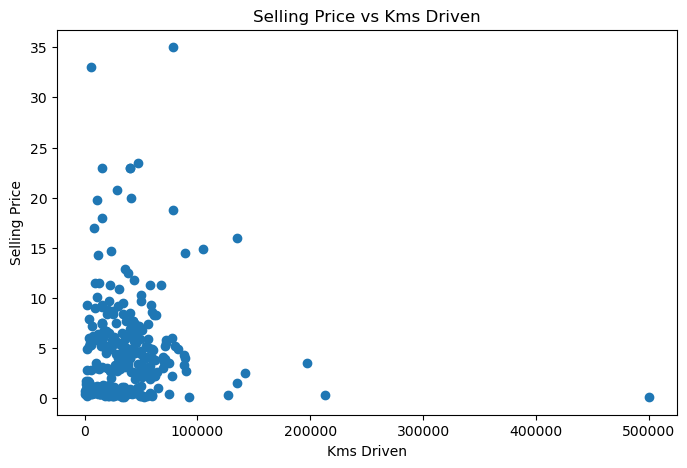

In [30]:
plt.figure(figsize=(8,5))

plt.scatter(df["Kms_Driven"], df["Selling_Price"])

plt.xlabel("Kms Driven")
plt.ylabel("Selling Price")
plt.title("Selling Price vs Kms Driven")

plt.show()

In [31]:
new_vehicles = df[df["Year"] > 2014]

print("Vehicles manufactured after 2014:",
      len(new_vehicles))

Vehicles manufactured after 2014: 147


In [32]:
bike_keywords = [
    "Activa", "Bajaj", "Hero", "Honda CB", "Honda CBR",
    "Honda Dream", "Honda Karizma", "Hyosung", "KTM",
    "Mahindra Mojo", "Royal Enfield", "Suzuki Access",
    "TVS Apache", "TVS Jupyter", "TVS Sport", "TVS Wego",
    "UM Renegade", "Yamaha FZ", "Yamaha Fazer"
]

pattern = "|".join(bike_keywords)

two_wheeler = df[
    df["Car_Name"].str.contains(
        pattern,
        case=False,
        regex=True,
        na=False
    )
]

print("Two Wheelers:", len(two_wheeler))

Two Wheelers: 101


In [33]:
oldest_bike = two_wheeler.loc[
    two_wheeler["Year"].idxmin()
]

print(oldest_bike[[
    "Car_Name",
    "Year",
    "Selling_Price"
]])

Car_Name         Hero Super Splendor
Year                            2005
Selling_Price                    0.2
Name: 189, dtype: object


In [34]:
newest_bike = two_wheeler.loc[
    two_wheeler["Year"].idxmax()
]

print(newest_bike[[
    "Car_Name",
    "Year",
    "Selling_Price"
]])

Car_Name         UM Renegade Mojave
Year                           2017
Selling_Price                   1.7
Name: 101, dtype: object


In [35]:
print(
    two_wheeler["Car_Name"]
    .value_counts()
    .head(10)
)

Car_Name
Royal Enfield Classic 350    7
Bajaj Pulsar 150             4
Royal Enfield Thunder 350    4
Bajaj Pulsar NS 200          3
TVS Apache RTR 160           3
Yamaha FZ S V 2.0            3
Honda CB Hornet 160R         3
Bajaj Avenger 220            3
Royal Enfield Thunder 500    3
Honda Activa 4G              2
Name: count, dtype: int64


In [36]:
from sklearn.linear_model import LinearRegression

In [37]:
bike_data = two_wheeler.copy()

X = bike_data[["Age", "Kms_Driven"]]
y = bike_data["Selling_Price"]

model = LinearRegression()

model.fit(X, y)

bike_data["Expected_Price"] = model.predict(X)

bike_data["Difference"] = (
    bike_data["Selling_Price"] -
    bike_data["Expected_Price"]
)

print(
    bike_data.sort_values(
        "Difference",
        ascending=False
    )[[
        "Car_Name",
        "Year",
        "Kms_Driven",
        "Selling_Price",
        "Expected_Price",
        "Difference"
    ]].head(10)
)

                      Car_Name  Year  Kms_Driven  Selling_Price  \
100  Royal Enfield Thunder 500  2016        3000           1.75   
101         UM Renegade Mojave  2017        1400           1.70   
102                  KTM RC200  2017        4000           1.65   
106             Hyosung GT250R  2014       16500           1.35   
107  Royal Enfield Thunder 350  2013       15000           1.25   
105                  KTM RC390  2015       21700           1.35   
103          Bajaj Dominar 400  2017        1200           1.45   
121  Royal Enfield Thunder 350  2011        6900           1.05   
125  Royal Enfield Classic 500  2009       40000           0.90   
116  Royal Enfield Classic 350  2013       33000           1.10   

     Expected_Price  Difference  
100        0.799198    0.950802  
101        0.862038    0.837962  
102        0.860334    0.789666  
106        0.666764    0.683236  
107        0.605955    0.644045  
105        0.725147    0.624853  
103        0.862169    0

In [38]:
cars = df[
    ~df["Car_Name"].str.contains(
        pattern,
        case=False,
        regex=True,
        na=False
    )
]

print("Number of Cars:", len(cars))

Number of Cars: 200


In [39]:
oldest_car = cars.loc[cars["Year"].idxmin()]

print(oldest_car[[
    "Car_Name",
    "Year",
    "Selling_Price"
]])

Car_Name          800
Year             2003
Selling_Price    0.35
Name: 37, dtype: object


In [40]:
newest_car = cars.loc[cars["Year"].idxmax()]

print(newest_car[[
    "Car_Name",
    "Year",
    "Selling_Price"
]])

Car_Name         vitara brezza
Year                      2018
Selling_Price             9.25
Name: 5, dtype: object


In [41]:
car_data = cars.copy()

X = car_data[["Age", "Kms_Driven"]]
y = car_data["Selling_Price"]

model = LinearRegression()

model.fit(X, y)

car_data["Expected_Price"] = model.predict(X)

car_data["Difference"] = (
    car_data["Selling_Price"] -
    car_data["Expected_Price"]
)

print(
    car_data.sort_values(
        "Difference",
        ascending=False
    )[[
        "Car_Name",
        "Year",
        "Kms_Driven",
        "Selling_Price",
        "Expected_Price",
        "Difference"
    ]].head(10)
)

        Car_Name  Year  Kms_Driven  Selling_Price  Expected_Price  Difference
86  land cruiser  2010       78000          35.00        5.103475   29.896525
64      fortuner  2017        6000          33.00        8.167023   24.832977
63      fortuner  2015       47000          23.50        8.343004   15.156996
93      fortuner  2015       40000          23.00        7.982775   15.017225
51      fortuner  2015       40000          23.00        7.982775   15.017225
82        innova  2017       15000          23.00        8.630174   14.369826
59      fortuner  2014       41000          19.99        7.067270   12.922730
96        innova  2016       29000          20.75        8.383667   12.366333
66        innova  2017       11000          19.75        8.424329   11.325671
62      fortuner  2014       78000          18.75        8.971339    9.778661


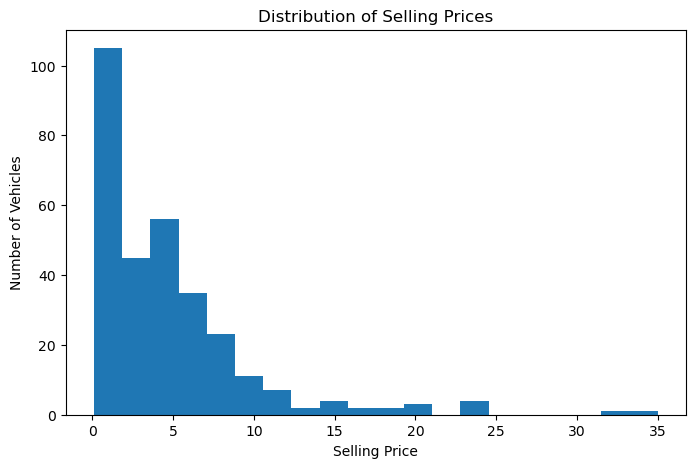

In [42]:
plt.figure(figsize=(8,5))

plt.hist(df["Selling_Price"], bins=20)

plt.xlabel("Selling Price")
plt.ylabel("Number of Vehicles")
plt.title("Distribution of Selling Prices")

plt.show()

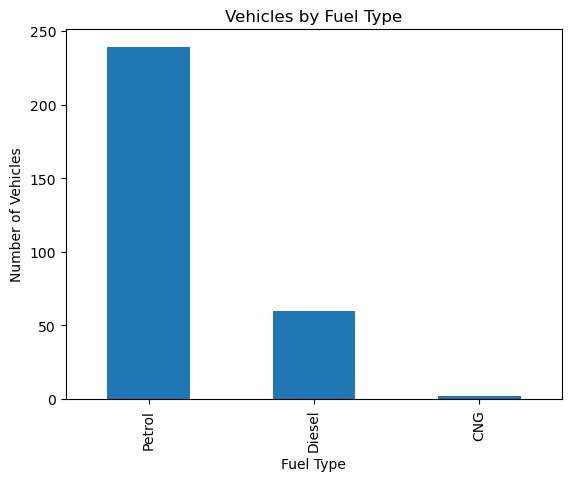

In [43]:
df["Fuel_Type"].value_counts().plot(kind="bar")

plt.xlabel("Fuel Type")
plt.ylabel("Number of Vehicles")
plt.title("Vehicles by Fuel Type")

plt.show()

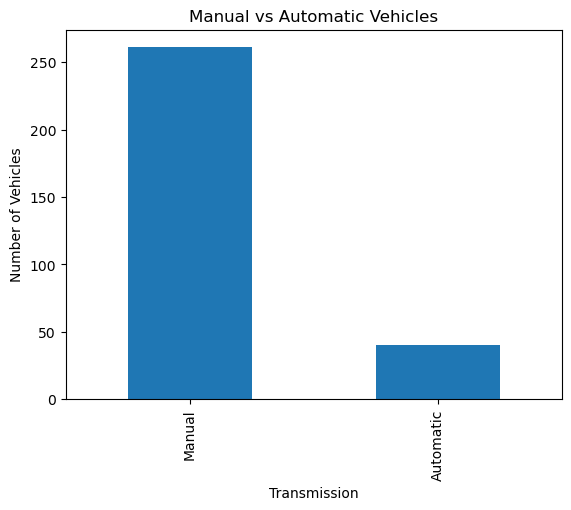

In [44]:
df["Transmission"].value_counts().plot(kind="bar")

plt.xlabel("Transmission")
plt.ylabel("Number of Vehicles")
plt.title("Manual vs Automatic Vehicles")

plt.show()

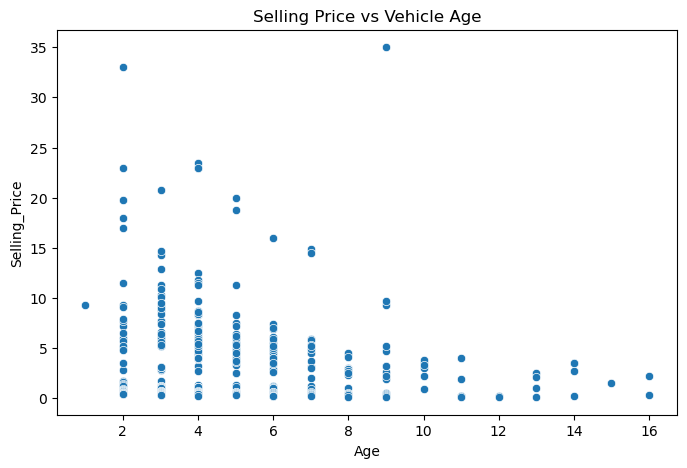

In [45]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="Age",
    y="Selling_Price"
)

plt.title("Selling Price vs Vehicle Age")
plt.show()

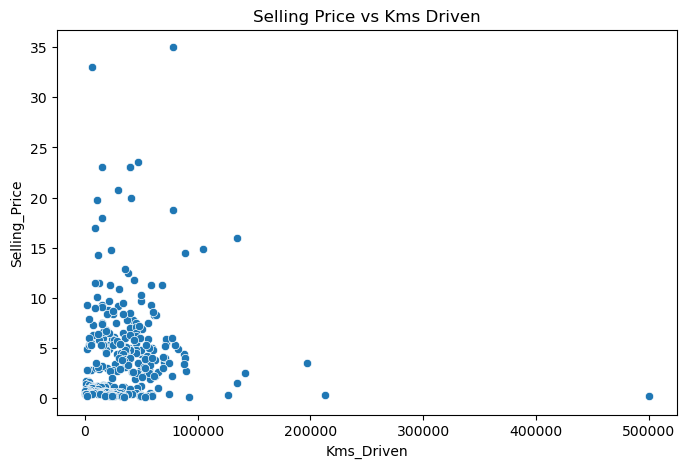

In [46]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="Kms_Driven",
    y="Selling_Price"
)

plt.title("Selling Price vs Kms Driven")
plt.show()